# Phase 5 — SHAP Explainability + Retention Levers

**Goal:** turn the churn model from a black box into a decision-support tool. For each
flagged subscriber, we explain **why** the model flagged them AND **which retention
lever** the PM should pull.

**Two audiences:**
- **Data science** — proper SHAP methodology (TreeExplainer, log-odds space, global vs
  local, ranked importance)
- **Product** — feature → intervention mapping curated with the PM, three worked
  examples showing *"flag + why + what to do"*

## Sections

| Section | Purpose |
|---|---|
| **A. Setup** | Load features, retrain uncalibrated XGB (SHAP needs the raw booster) |
| **B. Compute SHAP** | TreeExplainer on a 2K test sample |
| **C. Global importance** | Mean-abs-SHAP ranked feature table + bar chart |
| **D. Beeswarm** | Direction + magnitude across the sample |
| **E. Dependence** | How SHAP shifts with feature value for the top 3 drivers |
| **F. Local explanations** | Three worked examples: HIGH / MARGINAL / LOW risk |
| **G. Intervention map** | Feature → lever + cost lookup table |
| **H. Verdict** | Handoff to Phase 6 decision rule |

All figures saved under `reports/figures/`.

In [1]:
import os
import sys
from pathlib import Path

# Run from project root whether invoked as `python notebooks/05_...` or
# from a Jupyter cell (which doesn't define __file__).
try:
    _project_root = Path(__file__).resolve().parents[1]
except NameError:
    _here = Path.cwd()
    _project_root = _here.parent if _here.name == "notebooks" else _here
os.chdir(_project_root)
sys.path.insert(0, str(_project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from sklearn.model_selection import train_test_split

from src.data.loader import load_subscribers
from src.features.transforms import build_features
from src.models.train import prepare_features, train_xgboost
from src.models.explain import (
    compute_shap_values, global_importance, local_explanation,
    map_to_intervention, FEATURE_INTERVENTION_MAP,
)

FIG_DIR = Path("reports/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

## A. Setup — retrain uncalibrated XGB for SHAP

The calibrated model runs in production for probabilities; this uncalibrated version
is what runs SHAP because TreeExplainer needs direct access to the booster's tree
structure. Same three-way split as Phase 4 (same seed) so we're explaining the same
model on the same test users.

In [2]:
print("=" * 70)
print("A. SETUP -- load model + test features")
print("=" * 70)

raw = load_subscribers("data/subscribers.csv")
df = build_features(raw)
X, y = prepare_features(df)

# Same three-way split as Phase 4 (same seed) so we're explaining the
# same model on the same test users.
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42,
)
X_train, X_calib, y_train, y_calib = train_test_split(
    X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=42,
)

# Retrain uncalibrated XGBoost -- SHAP needs direct access to the tree
# structure. The calibrated model is what runs in production for
# probabilities; this one is what runs SHAP.
xgb = train_xgboost(X_train, y_train)
print(f"Retrained XGBoost on train (n={len(X_train):,}) for SHAP analysis")

A. SETUP -- load model + test features
Retrained XGBoost on train (n=30,000) for SHAP analysis


## B. Compute SHAP values (TreeExplainer)

Sample 2,000 test users — SHAP over the full test set is unnecessary and slow. Global
patterns show up cleanly at n=2000. Sanity-check that
`sum(SHAP) + base_value == raw model margin`.

In [3]:
print("\n" + "=" * 70)
print("B. COMPUTE SHAP VALUES (TreeExplainer)")
print("=" * 70)
SAMPLE_SIZE = 2000
shap_values = compute_shap_values(xgb, X_test, sample_size=SAMPLE_SIZE)
X_shap = X_test.sample(n=SAMPLE_SIZE, random_state=42)
y_shap = y_test.loc[X_shap.index]
print(f"Computed SHAP for {SAMPLE_SIZE} test users")
print(f"Base value (expected log-odds output): {shap_values.base_values[0]:.4f}")
print(f"Base value (as probability): {1/(1+np.exp(-shap_values.base_values[0])):.4f}")
# Sanity check: sum(SHAP) + base_value == raw model output
sample_pred = xgb.predict(X_shap.iloc[[0]], output_margin=True)[0]
sample_check = shap_values.values[0].sum() + shap_values.base_values[0]
print(f"Sanity check (should match): raw margin={sample_pred:.4f}, "
      f"sum(shap)+base={sample_check:.4f}")


B. COMPUTE SHAP VALUES (TreeExplainer)
Computed SHAP for 2000 test users
Base value (expected log-odds output): -2.9097
Base value (as probability): 0.0517
Sanity check (should match): raw margin=-3.8993, sum(shap)+base=-3.8993


## C. Global feature importance — mean |SHAP|

Ranked feature contribution to the model's log-odds output. Bar-chart color encodes
average direction: red bars push toward churn, green push away.


C. GLOBAL FEATURE IMPORTANCE (mean |SHAP|)
               feature  mean_abs_shap  mean_signed_shap
   watch_hours_last_7d       0.275681         -0.081516
  billing_cycle_annual       0.247276         -0.055661
 days_since_last_login       0.228046         -0.060274
  payment_health_score       0.188039         -0.029581
         tenure_months       0.161667         -0.034980
       logins_last_30d       0.153866         -0.035615
 watch_trend_7d_to_30d       0.150383         -0.047375
         multi_profile       0.098942         -0.010412
watch_trend_30d_to_90d       0.097465         -0.025165
  watch_hours_last_90d       0.089099         -0.041478
     plan_tier_Premium       0.082241         -0.009907
       plan_tier_Basic       0.075119         -0.004636
tenure_bucket_m2_trial       0.073848         -0.009439
   watch_per_login_30d       0.065865         -0.010744
   distinct_titles_90d       0.063333          0.029168

Saved -> reports\figures/05_shap_global_importance.png


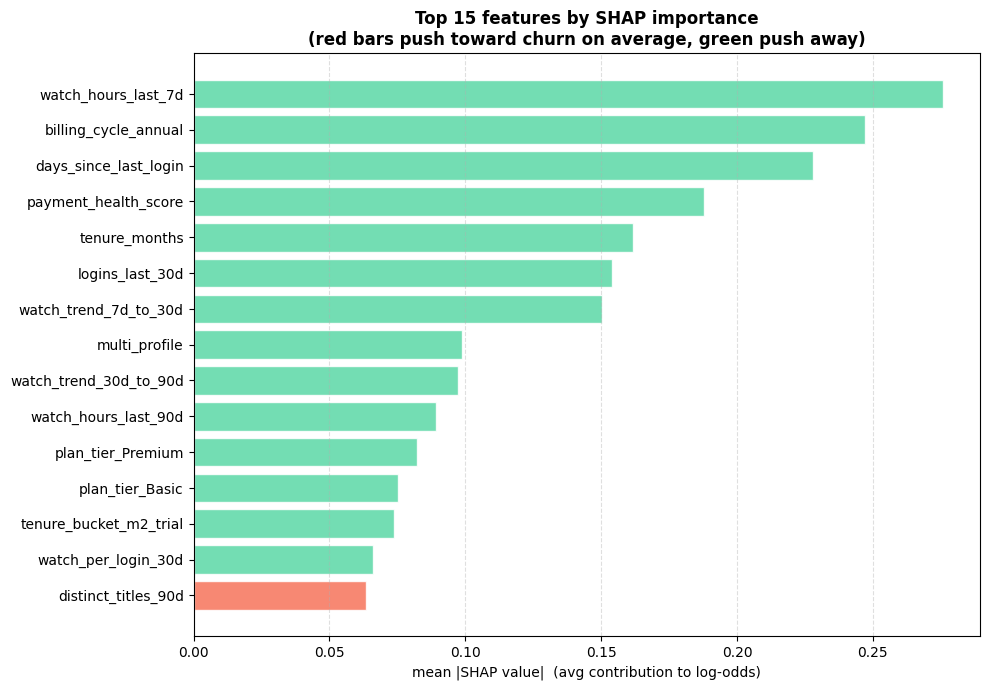

In [4]:
print("\n" + "=" * 70)
print("C. GLOBAL FEATURE IMPORTANCE (mean |SHAP|)")
print("=" * 70)
importance = global_importance(shap_values, list(X_shap.columns), top_n=15)
print(importance.to_string(index=False))

# Bar chart
fig, ax = plt.subplots(figsize=(10, 7))
colors = ["#F6735B" if v > 0 else "#5AD8A6"
          for v in importance["mean_signed_shap"]]
ax.barh(importance["feature"][::-1], importance["mean_abs_shap"][::-1],
        color=colors[::-1], alpha=0.85, edgecolor="white")
ax.set_xlabel("mean |SHAP value|  (avg contribution to log-odds)")
ax.set_title("Top 15 features by SHAP importance\n"
             "(red bars push toward churn on average, green push away)",
             fontweight="bold")
ax.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(FIG_DIR / "05_shap_global_importance.png",
            dpi=140, bbox_inches="tight")
print(f"\nSaved -> {FIG_DIR}/05_shap_global_importance.png")

## D. SHAP summary plot (beeswarm)

One row per feature, one dot per user. X-position = SHAP contribution, color = feature
value (red high, blue low). Shows **both magnitude and direction** of effect across
the sample in one image.

In [5]:
print("\n" + "=" * 70)
print("D. SHAP SUMMARY PLOT (beeswarm)")
print("=" * 70)
plt.figure(figsize=(11, 8))
shap.summary_plot(shap_values, X_shap, max_display=15, show=False,
                  plot_size=None)
plt.title("SHAP summary -- direction and magnitude of top features",
          fontweight="bold", pad=20)
plt.tight_layout()
plt.savefig(FIG_DIR / "05_shap_beeswarm.png", dpi=140, bbox_inches="tight")
plt.close()
print(f"Saved -> {FIG_DIR}/05_shap_beeswarm.png")


D. SHAP SUMMARY PLOT (beeswarm)
Saved -> reports\figures/05_shap_beeswarm.png


## E. Feature dependence for top 3 drivers

Scatter of feature value (x) vs SHAP contribution (y) for the three most important
features. Reveals thresholds and non-linearities the tree learned.


E. FEATURE DEPENDENCE (top 3 drivers)
Saved -> reports\figures/05_shap_dependence.png

Top 3 drivers:
  - watch_hours_last_7d
  - billing_cycle_annual
  - days_since_last_login


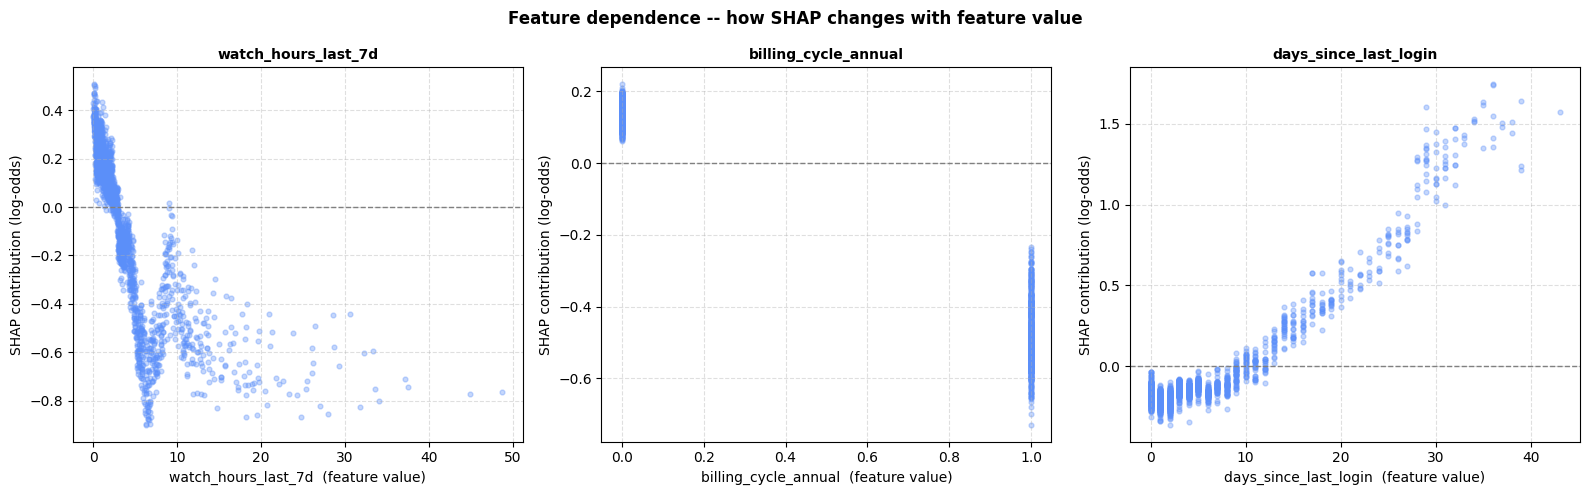

In [6]:
print("\n" + "=" * 70)
print("E. FEATURE DEPENDENCE (top 3 drivers)")
print("=" * 70)
top_3 = importance["feature"].head(3).tolist()
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, feat in zip(axes, top_3):
    idx = list(X_shap.columns).index(feat)
    x = X_shap.iloc[:, idx].values
    s = shap_values.values[:, idx]
    ax.scatter(x, s, alpha=0.35, s=12, color="#5B8FF9")
    ax.axhline(0, color="gray", linestyle="--", linewidth=1)
    ax.set_xlabel(f"{feat}  (feature value)")
    ax.set_ylabel("SHAP contribution (log-odds)")
    ax.set_title(feat, fontweight="bold", fontsize=10)
    ax.grid(True, linestyle="--", alpha=0.4)

plt.suptitle("Feature dependence -- how SHAP changes with feature value",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "05_shap_dependence.png", dpi=140, bbox_inches="tight")
print(f"Saved -> {FIG_DIR}/05_shap_dependence.png")
print(f"\nTop 3 drivers:")
for feat in top_3:
    print(f"  - {feat}")

## F. Local explanations — three worked examples

Pick one user at each risk tier (highest, marginal, lowest) and walk through the top
SHAP contributions. Attach the recommended intervention for the top `RISK+` feature.
This is the pattern the Streamlit app uses in the Per-user lookup tab.

In [7]:
print("\n" + "=" * 70)
print("F. LOCAL EXPLANATIONS -- three worked examples")
print("=" * 70)

pred_proba = xgb.predict_proba(X_shap)[:, 1]
# Pick three example indices at different risk levels
# 1. Highest-risk user (model most confident of churn)
# 2. Marginal case near decision boundary
# 3. Confidently retained user (control example)
example_indices = [
    ("HIGH RISK   ", int(np.argmax(pred_proba))),
    ("MARGINAL    ", int(np.argmin(np.abs(pred_proba - 0.15)))),
    ("LOW RISK    ", int(np.argmin(pred_proba))),
]

for label, idx in example_indices:
    p = pred_proba[idx]
    actual = int(y_shap.iloc[idx])
    print(f"\n[{label}]  P(churn)={p:.3f}  actual={actual}")
    local = local_explanation(shap_values, X_shap, list(X_shap.columns),
                              idx=idx, top_n=6)
    print(local.to_string(index=False))

    # Attach the intervention recommendation for the top RISK+ feature
    top_risk = local[local["direction"] == "RISK+"].head(1)
    if not top_risk.empty:
        feat = top_risk["feature"].iloc[0]
        lever = map_to_intervention(feat)
        print(f"  Top intervention lever: {lever['lever']}  (cost=${lever['cost']:.0f})")
        print(f"  Reason: {lever['note']}")


F. LOCAL EXPLANATIONS -- three worked examples

[HIGH RISK   ]  P(churn)=0.569  actual=0
              feature  feature_value  shap_value direction
days_since_last_login      32.000000    1.307050     RISK+
watch_trend_7d_to_30d       0.568272    0.591709     RISK+
      logins_last_30d       2.000000    0.326750     RISK+
 payment_health_score       1.000000    0.274103     RISK+
 watch_hours_last_90d      80.300000   -0.163959     RISK-
  watch_per_login_30d       9.050000   -0.156636     RISK-
  Top intervention lever: Re-engagement email sequence  (cost=$1)
  Reason: Inactive users need a reason to come back

[MARGINAL    ]  P(churn)=0.150  actual=0
               feature  feature_value  shap_value direction
 days_since_last_login      30.000000    1.048047     RISK+
tenure_bucket_m2_trial       1.000000    0.589098     RISK+
   watch_hours_last_7d       6.600000   -0.544307     RISK-
 watch_trend_7d_to_30d       1.188475   -0.359433     RISK-
       logins_last_30d       3.000000

## G. Feature → intervention mapping table

The bridge between model and decision rule. Every flagged feature has a paired lever
(or "no lever" if the feature is diagnostic-only). This mapping was curated with the
PM and lives in `src/models/explain.py:FEATURE_INTERVENTION_MAP`.

In [8]:
print("\n" + "=" * 70)
print("G. FEATURE -> INTERVENTION MAPPING")
print("=" * 70)
lever_rows = []
for feat, spec in FEATURE_INTERVENTION_MAP.items():
    lever_rows.append({
        "feature": feat,
        "lever": spec["lever"],
        "cost": spec["cost"],
        "note": spec["note"],
    })
lever_df = pd.DataFrame(lever_rows)
print(lever_df.to_string(index=False))


G. FEATURE -> INTERVENTION MAPPING
                       feature                                    lever  cost                                                                   note
         watch_trend_7d_to_30d                Personalized content push   1.0             Declining engagement -> curated playlist push notification
        watch_trend_30d_to_90d                Personalized content push   1.0        Slow-burn disengagement -> re-engagement email + trailer bundle
         days_since_last_login             Re-engagement email sequence   1.0                              Inactive users need a reason to come back
               logins_last_30d             Re-engagement email sequence   1.0                             Low login frequency -> weekly recap emails
            support_tickets_7d             White-glove support callback   5.0                 Recent ticket escalation -> proactive support outreach
         tickets_recency_ratio             White-glove support callbac

## H. Verdict + handoff to Phase 6

Roll up the top drivers, count how many have actionable levers, and describe what
Phase 6 will consume: per-user P(churn), top SHAP driver, lever cost, lever uplift,
LTV by tier.

In [9]:
print("\n" + "=" * 70)
print("H. PHASE 5 VERDICT")
print("=" * 70)
top_5 = importance.head(5)["feature"].tolist()
print(f"\nTop 5 SHAP drivers overall:")
for feat in top_5:
    lever = map_to_intervention(feat)
    print(f"  - {feat:<35}  lever: {lever['lever']}")
print(
    f"\nOf the top 15 features, "
    f"{sum(1 for f in importance['feature'] if map_to_intervention(f)['cost'] > 0)}"
    f" have an actionable intervention lever."
)
print("\nHandoff to Phase 6 (cost-aware decision rule):")
print("  - Per-user P(churn) from the calibrated XGBoost")
print("  - Per-user top SHAP driver from this notebook")
print("  - Intervention cost + expected uplift from the lever mapping above")
print("  - LTV by plan tier from the scenario brief")
print("\nDecision rule = argmax over levers of (P(churn) x uplift x LTV - cost).")


H. PHASE 5 VERDICT

Top 5 SHAP drivers overall:
  - watch_hours_last_7d                  lever: N/A (diagnostic feature)
  - billing_cycle_annual                 lever: Upgrade-to-annual offer
  - days_since_last_login                lever: Re-engagement email sequence
  - payment_health_score                 lever: Payment method update prompt + $5 credit
  - tenure_months                        lever: N/A -- structural signal

Of the top 15 features, 6 have an actionable intervention lever.

Handoff to Phase 6 (cost-aware decision rule):
  - Per-user P(churn) from the calibrated XGBoost
  - Per-user top SHAP driver from this notebook
  - Intervention cost + expected uplift from the lever mapping above
  - LTV by plan tier from the scenario brief

Decision rule = argmax over levers of (P(churn) x uplift x LTV - cost).
